In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')

from utils import *
from matplotlib.collections import PolyCollection

circle = Hypersphere(1)
manifold_type = 'S1'


# Set Parameters

In [11]:
n_samples = 1000
sigma2 = .05

# densitiy estimation
M = 4
rho = 1e-5

# prior param
num_modes = 4
tau2 = 0.01/num_modes
G_params = {'tau2': tau2, 'num_modes': num_modes} 


In [12]:
Theta = S1_multimodal_prior(n_samples, G_params)
X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)

In [13]:
delta = denoiser('S1', X, M, rho, sigma2, X, stepsize = 1, reps = 1)

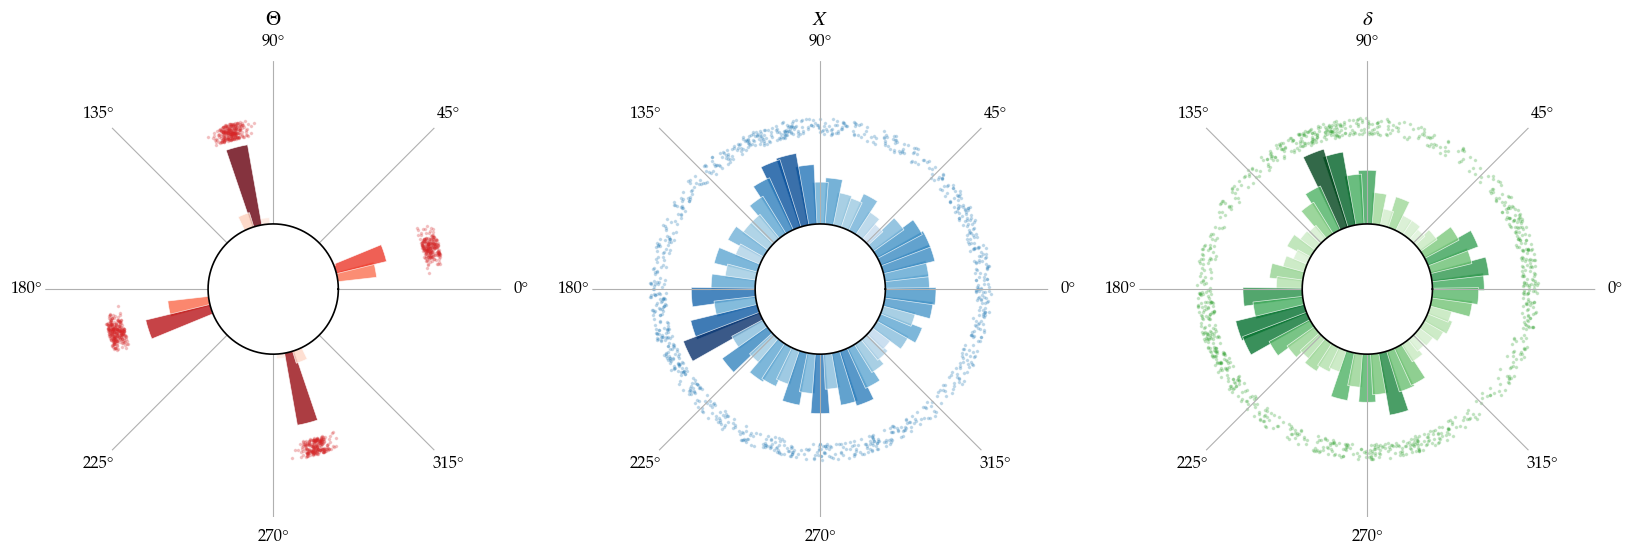

N : 0.229
D : 0.211
0.07


In [14]:
fig, axs = plt.subplots(1,3, figsize = (20,10), subplot_kw={'polar':True}, sharey=True)

size = 2.5; jitter_std = 5e-2; alpha = .2

S1_scatter(Theta, axs[0], 'C3', alpha, size, '$\Theta$', jitter_std)
S1_scatter(X, axs[1], 'C0', alpha, size, '$X$', jitter_std)
S1_scatter(delta, axs[2], 'C2', alpha, size, '$\delta$', jitter_std)

nbins = 50
S1_histogram(Theta, nbins, axs[0], 'Reds', '$\Theta$', .5)
S1_histogram(X, nbins, axs[1], 'Blues', '$X$', .5)
S1_histogram(delta, nbins, axs[2], 'Greens', '$\delta$', .5)
plt.show()

loss_N = (circle.metric.dist_broadcast(X, Theta)**2).mean()
loss_T = (circle.metric.dist_broadcast(delta, Theta)**2).mean()     

print('N : {:.3f}\nD : {:.3f}'.format(loss_N, loss_T))
print('{:.2f}'.format(1- loss_T/loss_N))

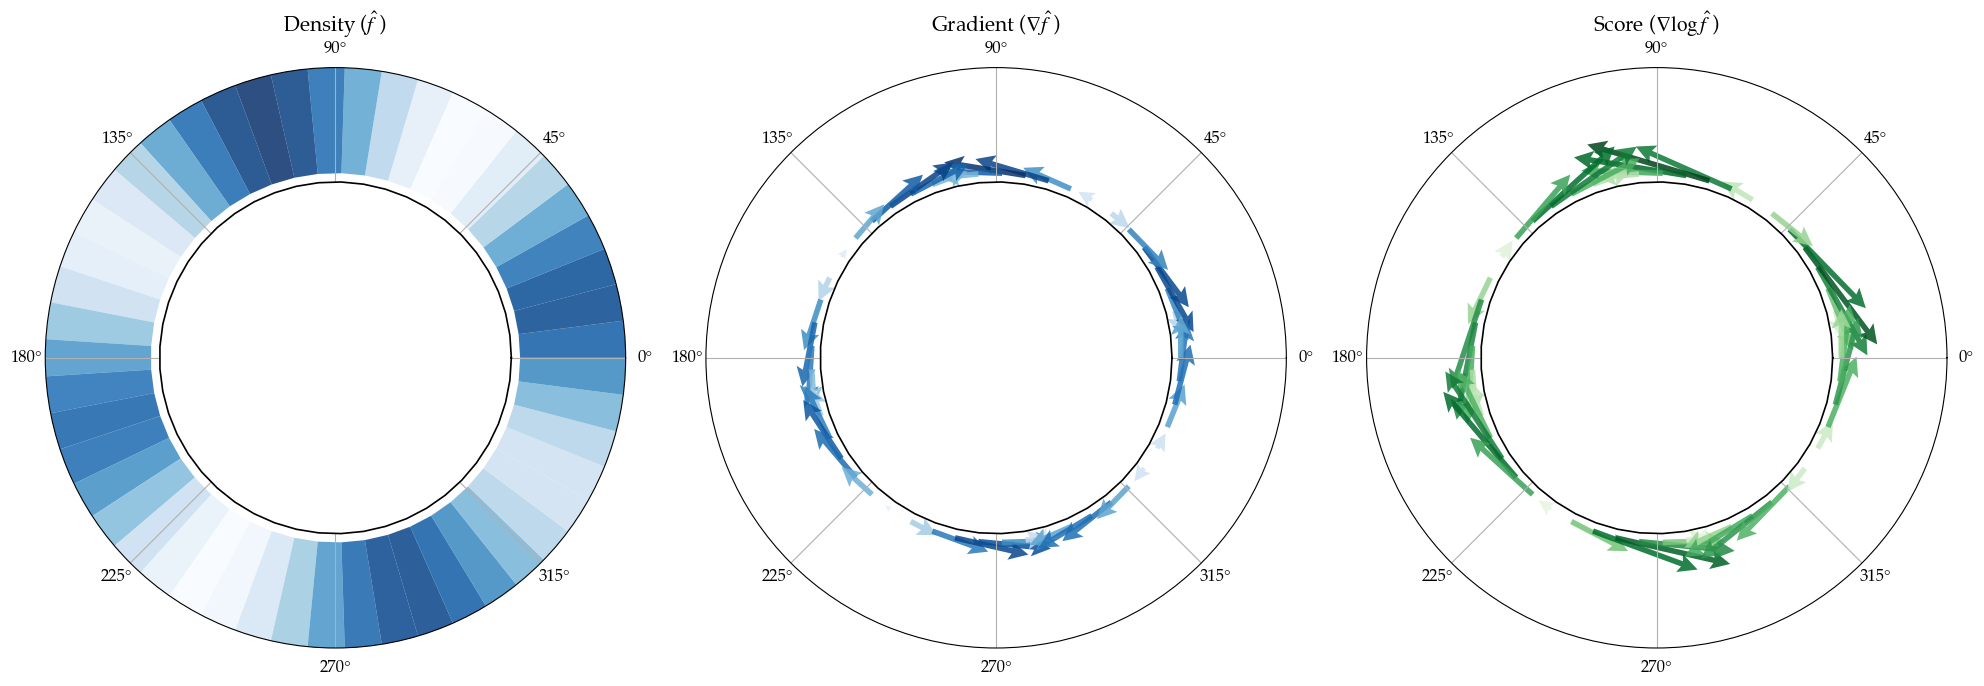

In [30]:
grid_I = np.linspace(0, 2*np.pi, 50)
grid = np.stack([np.cos(grid_I), np.sin(grid_I)], axis=1)
_, hat_f, hat_grad_f = density_estimate('S1', X, M, grid)

tangent_vectors = hat_grad_f[:, None] * np.stack([-np.sin(grid_I), np.cos(grid_I)], axis=1)

fig, axs = plt.subplots(1, 3, figsize=(20, 10), subplot_kw={'polar': True})
f_scale = 0.3
bottom = 0.105
top = .5
disk_r = 0.1

# ---------- DENSITY ---------------------------------------------------------------------------
hat_pos_f = np.maximum(hat_f, 0)
normalised_hat_f = (hat_pos_f - hat_pos_f.min()) / (hat_pos_f.max() - hat_pos_f.min() + 1e-10)
verts = [[
        (grid_I[i], bottom),
        # (grid_I[i], bottom + f_scale * hat_pos_f[i]), (grid_I[i+1], bottom + f_scale * hat_pos_f[i+1]),
        (grid_I[i],top), (grid_I[i+1], bottom + top),
        (grid_I[i+1], bottom)
    ] for i in range(len(grid_I) - 1)] # Create polygon vertices for each segment
poly = PolyCollection(verts, facecolors=plt.colormaps['Blues'](normalised_hat_f[:-1]), 
                      alpha=0.85, edgecolors='none')
axs[0].add_collection(poly)
# axs[0].plot(grid_I, bottom + f_scale*hat_pos_f, color='darkblue', linewidth=.5, alpha=0.85)
axs[0].set_title('Density ($\hat f$)', fontsize=15)

# ---------- GRADIENT ---------------------------------------------------------------------------
vector_lengths = np.linalg.norm(tangent_vectors, axis=1)
axs[1].quiver(
    grid_I,                         
    np.ones_like(grid_I)*bottom,    
    tangent_vectors[:, 0],          
    tangent_vectors[:, 1],          
    vector_lengths,                 
    scale=4,           
    width=0.0095,         
    headwidth=3.5,        
    headlength=3.5,       
    headaxislength=3, 
    cmap='Blues',       
    alpha=0.85,         
    edgecolors=None,     
    linewidths=0.25,     
)
axs[1].set_title('Gradient ($\\nabla \hat f$)', fontsize=15)

# ---------- SCORE ---------------------------------------------------------------------------
hat_score = hat_grad_f / np.maximum(rho, hat_f)
tangent_vectors = hat_score[:, None] * np.stack([-np.sin(grid_I), np.cos(grid_I)], axis=1)

vector_lengths = np.linalg.norm(tangent_vectors, axis=1)
axs[2].quiver(
    grid_I,                         
    np.ones_like(grid_I)*bottom,    
    tangent_vectors[:, 0],          
    tangent_vectors[:, 1],          
    vector_lengths,                 
    scale=7,           
    width=0.0095,         
    headwidth=3.5,        
    headlength=3.5,       
    headaxislength=3, 
    cmap='Greens',       
    alpha=0.85,         
    edgecolors=None,     
    linewidths=0.25,     
)
axs[2].set_title('Score ($\\nabla \log \hat f$)', fontsize=15)

# -------------------------------------------------------------------------------------

# Set consistent limits and styling for both axes
for ax in axs: 
    ax.set_ylim(0, bottom + f_scale*.2)  # Set proper radial limits
    ax.set_yticks([])
    ax.bar(0, disk_r, width=2*np.pi, bottom=0, color="white", edgecolor="none", align="edge", zorder=3)
    ax.plot(grid_I, disk_r*np.ones_like(grid_I), color='black', linewidth=1.2, zorder=4)

plt.tight_layout()

plt.show()

<!-- # Visualisation -->

-----

# Oracle

In [ ]:
n_samples = 1000
num_oracle_samples = 10000
oracle_bandwidth = 0.01

# latent distribution parameters
num_modes = 4
tau2 = 0.01/num_modes
G_params = {'tau2': tau2, 'num_modes': num_modes} 

# obs noise variance
sigma2 = 0.05

# --- sampling
Theta = S1_multimodal_prior(n_samples, G_params)
X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)

In [ ]:
# ESTIMATED
delta = denoiser(manifold_type, X, M, rho, sigma2, X, stepsize = 1, reps = 1)

# ORACLE
oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, G_params, sigma2, oracle_bandwidth, X)
oracle_delta_B = oracle_bayes(manifold_type,  num_oracle_samples, G_params, sigma2, oracle_bandwidth, X)

# ----- compare losses -----
oracle_bayes_loss = circle.metric.dist_broadcast(oracle_delta_B, Theta)**2
print('Oracle Bayes Loss: {:.3f}'.format(oracle_bayes_loss.mean()))

oracle_delta_loss = circle.metric.dist_broadcast(oracle_delta_T, Theta)**2
print('Oracle Denoiser Loss: {:.3f}'.format(oracle_delta_loss.mean()))

estimated_delta_loss = circle.metric.dist_broadcast(delta, Theta)**2
print('Estimated Denoiser Loss: {:.3f}'.format(estimated_delta_loss.mean()))



Denoising: 100%|██████████| 1000/1000 [00:00<00:00, 2039.38it/s]

Oracle Bayes Loss: 0.171
Oracle Denoiser Loss: 0.174
Estimated Denoiser Loss: 0.203
